In [21]:
from itertools import count

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import subplots_adjust

#root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
#sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "18_ex_con_2025_full_logit_mean_one"

#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'alpha', 'g_stem_res','gam_stem_x_H','k_xyl_x_H', 'gam_stem_div_g0', 'g_min_loss']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close',  'alpha','psi88_xylem']

vars_plant_ex = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close',  'alpha','psi88_xylem', 'gam_stem_x_H','k_xyl_x_H', 'gam_stem_div_g0', 'g_min_loss']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.5]
df['alpha'] = df['g_stem_res']/ df['g0']
df['gam_stem_x_H'] = df['stem_hydraulic_capacitance'] * df['huber_value']
df['k_xyl_x_H'] = df['k_xylem_sat'] * df['huber_value']
df['gam_stem_div_g0'] = df['stem_hydraulic_capacitance']/ df['g0']
df['g_min_loss'] = df['g0'] + df['g_stem_res']
index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_plant_ex].mean()
df_mean.shape

(21263, 13)

In [10]:
df

,Unnamed: 0,index,id,root_area_index,canopy_height,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,...,t13,alive_mean,target_rmse,RMSE_MAX,sid,alpha,gam_stem_x_H,k_xyl_x_H,gam_stem_div_g0,g_min_loss
43679,4,2214,8735,8.119745,35,1800.0,1800,False,1.0,1.75,...,4.066384,4.509504,0.864514,0.960135,4,0.087368,2.940570,0.022829,8.191185e+06,0.001286
43675,0,9932,8735,8.050982,35,1800.0,1800,False,1.0,1.75,...,0.504654,0.460865,0.864514,0.960135,0,0.169586,2.747630,0.019364,1.090584e+07,0.000962
43676,1,4780,8735,10.719259,35,1800.0,1800,False,1.0,1.75,...,3.830970,4.501504,0.864514,0.960135,1,0.128629,2.548433,0.020127,1.135842e+07,0.000931
43678,3,3499,8735,8.105408,35,1800.0,1800,False,1.0,1.75,...,3.972117,4.477188,0.864514,0.960135,3,0.127727,2.851165,0.022723,1.119916e+07,0.000965
23049,4,4107,4609,7.950653,35,1800.0,1800,False,1.0,1.75,...,4.050318,4.493096,0.804822,0.964327,4,0.051053,3.074067,0.023327,1.100934e+07,0.001145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49645,0,6438,9929,5.900697,35,1800.0,1800,False,1.0,1.75,...,0.696991,0.668235,1.321075,1.499901,0,0.781367,3.565813,0.014474,6.223962e+06,0.002792
25018,3,3334,5003,6.116291,35,1800.0,1800,False,1.0,1.75,...,3.761234,4.232585,1.281142,1.499941,3,0.446020,5.913491,0.005105,1.955796e+07,0.001487
25019,4,9995,5003,6.651791,35,1800.0,1800,False,1.0,1.75,...,4.438561,4.978694,1.281142,1.499941,4,0.515192,4.346482,0.004636,1.988387e+07,0.001411
25015,0,1673,5003,6.082713,35,1800.0,1800,False,1.0,1.75,...,0.591262,0.719972,1.281142,1.499941,0,0.664079,8.731226,0.006404,3.122933e+07,0.001447


In [22]:
df_norm = (df_mean - df_mean.mean()) / df_mean.std()

In [23]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,psi_leaf_50_close,alpha,psi88_xylem
id,,,,,,,,,
0,-2.075361,0.592605,1.323261,0.083147,1.296405,-1.178961,-0.701196,-1.645368,1.179823
1,-1.528138,0.252471,0.918461,-1.304003,0.454311,-1.004153,0.758456,1.829854,0.336296
2,0.035869,1.241220,-0.814548,-1.280842,1.533501,-0.296534,-1.198834,-0.797272,0.972053
3,1.028610,0.459403,0.123068,-1.226649,-1.442952,0.152145,-0.951501,0.219833,-0.418946
4,0.536582,-0.898981,-1.547833,1.381555,-0.126296,-1.148813,0.112940,0.237411,-0.170082
...,...,...,...,...,...,...,...,...,...
23545,-1.289706,0.657880,0.933509,-0.584533,0.310054,0.917204,-1.217572,-1.546938,0.410678
23546,0.167588,-0.541080,-1.832946,-0.642246,-0.000086,-1.383980,1.610183,0.098572,0.789913
23547,0.135946,1.054175,-0.563072,1.636603,0.504404,0.368974,0.284401,-0.757851,0.540759


In [17]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [38]:
label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['d_50_close'] = r"$d_{Leaf, close}$"
label_dict['alpha'] = r"$\alpha$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{g_0}{\Gamma_\mathrm{Stem}}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"


unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['leaf_hydraulic_capacitance'] = "kg m-2 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "-"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['psi88_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g1'] = "-"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"
unit_dict['alpha'] = r"-"
unit_dict['gam_stem_x_H'] = r"-"
unit_dict['gam_stem_div_g0'] = r"-"
unit_dict['k_xyl_x_H'] =r"-"
unit_dict['g_min_loss'] = r"-"

In [24]:
df_norm[vars_plant_ex]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,psi_leaf_50_close,alpha,psi88_xylem,gam_stem_x_H,k_xyl_x_H,gam_stem_div_g0,g_min_loss
id,,,,,,,,,,,,,
0,-2.075361,0.592605,1.323261,0.083147,1.296405,-1.178961,-0.701196,-1.645368,1.179823,-1.968237,1.454959,-1.774723,-1.771598
1,-1.528138,0.252471,0.918461,-1.304003,0.454311,-1.004153,0.758456,1.829854,0.336296,-1.369887,0.825370,-1.148601,0.424792
2,0.035869,1.241220,-0.814548,-1.280842,1.533501,-0.296534,-1.198834,-0.797272,0.972053,-0.353390,0.700486,0.280204,-0.771075
3,1.028610,0.459403,0.123068,-1.226649,-1.442952,0.152145,-0.951501,0.219833,-0.418946,1.444122,0.485934,1.032561,0.269311
4,0.536582,-0.898981,-1.547833,1.381555,-0.126296,-1.148813,0.112940,0.237411,-0.170082,-0.275889,-1.489301,1.644087,-0.653276
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23545,-1.289706,0.657880,0.933509,-0.584533,0.310054,0.917204,-1.217572,-1.546938,0.410678,-1.038687,1.300112,-1.719123,-0.722291
23546,0.167588,-0.541080,-1.832946,-0.642246,-0.000086,-1.383980,1.610183,0.098572,0.789913,-0.787871,-1.346319,1.472030,-0.898470
23547,0.135946,1.054175,-0.563072,1.636603,0.504404,0.368974,0.284401,-0.757851,0.540759,-0.100946,0.692779,-0.141603,-0.370913


In [25]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(df_norm[vars_plant])

KMeans(n_clusters=3, random_state=0)

In [26]:
K = range(2, 12)
fits = []

scorss = []
for s in range(10):
    score = []
    for k in K:
        # train the model for current value of k on training data
        model = KMeans(n_clusters = k, random_state = s, n_init='auto').fit(df_norm[vars_plant_ex])

        # append the model to fits
        fits.append(model)

        # Append the silhouette score to scores
        score.append(silhouette_score(df_norm[vars_plant_ex], model.labels_, metric='euclidean'))
    scorss.append(score)
    print(s)


0
1
2
3
4
5
6
7
8
9


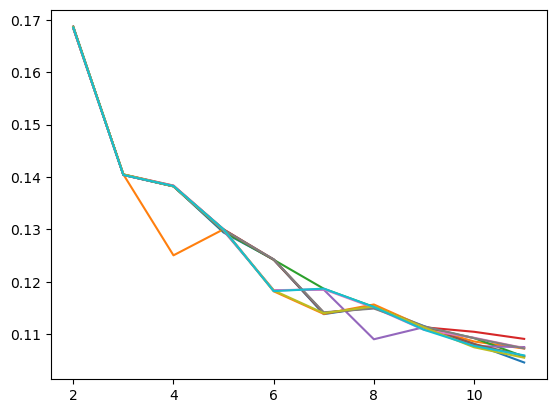

In [27]:
plt.plot(K, np.array(scorss).T);

In [29]:
kmeans = KMeans(n_clusters = 3, random_state = 9
                , n_init='auto')
kmeans.fit(df_norm[vars_plant_ex])
np.round(silhouette_score(df_norm[vars_plant_ex], kmeans.labels_, metric='euclidean'),3)


np.float64(0.14)

In [32]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
counts
countslabs = [f'G{i+1} ({counts[i]})'for i in range(3)]


In [34]:
vars_sel = vars_plant_ex

/tmp/ipykernel_3445777/43114986.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3445777/43114986.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3445777/43114986.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3445777/43114986.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3445777/43114986.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/

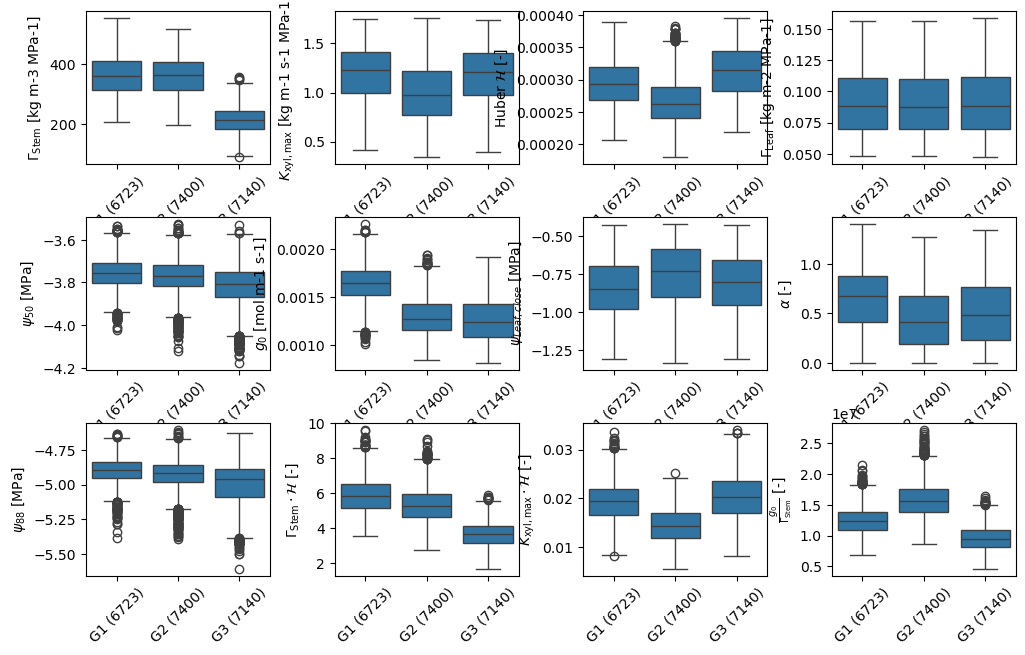

In [42]:
MOL_TO_KG = 18.0/1000.0 
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, 12+1), vars_sel):
    ax = fig.add_subplot(4,4, index)
    ax.set_xticklabels(countslabs)
    ax.set_ylabel(f"{label_dict[vars_sel[index-1]]} [{unit_dict[vars_sel[index-1]]}]")
    
    if  var == 'stem_hydraulic_capacitance':
        sns.boxplot(x = kmeans.labels_, y = df_mean[var] * MOL_TO_KG, ax=ax)
    elif var == 'k_xylem_sat':
        sns.boxplot(x = kmeans.labels_, y = df_mean[var] * MOL_TO_KG, ax=ax)
    else:
        sns.boxplot(x = kmeans.labels_, y = df_mean[var], ax=ax)
    ax.tick_params(axis='x', labelrotation=45)

plt.subplots_adjust(wspace=0.35, hspace=0.35)
plt.savefig(f"{post_path}/figure4_kmeans_cluster.png", bbox_inches='tight', dpi = 300)

In [28]:
from sklearn.cluster import MeanShift
from sklearn import metrics

db = MeanShift(bandwidth=2).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

KeyboardInterrupt: 

In [16]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,jackson_root_beta
id,,,,,,,,
0,-0.601464,1.145214,0.593686,1.227873,-2.142011,-2.047083,-0.991387,-0.736660
1,-0.505121,-0.872027,-0.098686,-0.794584,1.755737,1.980279,-1.392011,0.734571
2,1.412511,0.534290,0.514407,-0.280269,1.284822,1.306727,1.622993,2.429507
3,0.598750,-0.964184,0.907454,-0.669782,0.260972,1.040270,0.425506,0.440895
4,-0.263877,0.727996,0.548335,1.939314,0.978791,0.045805,0.180179,-0.495927
...,...,...,...,...,...,...,...,...
23694,-0.113747,0.276975,1.328484,1.707235,-0.075766,0.262491,2.640747,-1.652910
23695,-0.601057,-0.126646,-0.997181,-0.805152,1.175334,0.476110,-0.954902,0.152204
23696,0.553392,0.628877,0.964663,0.057998,0.602677,1.493658,0.034281,0.840595


In [ ]:
unique, counts = numpy.unique(a, return_counts=True)

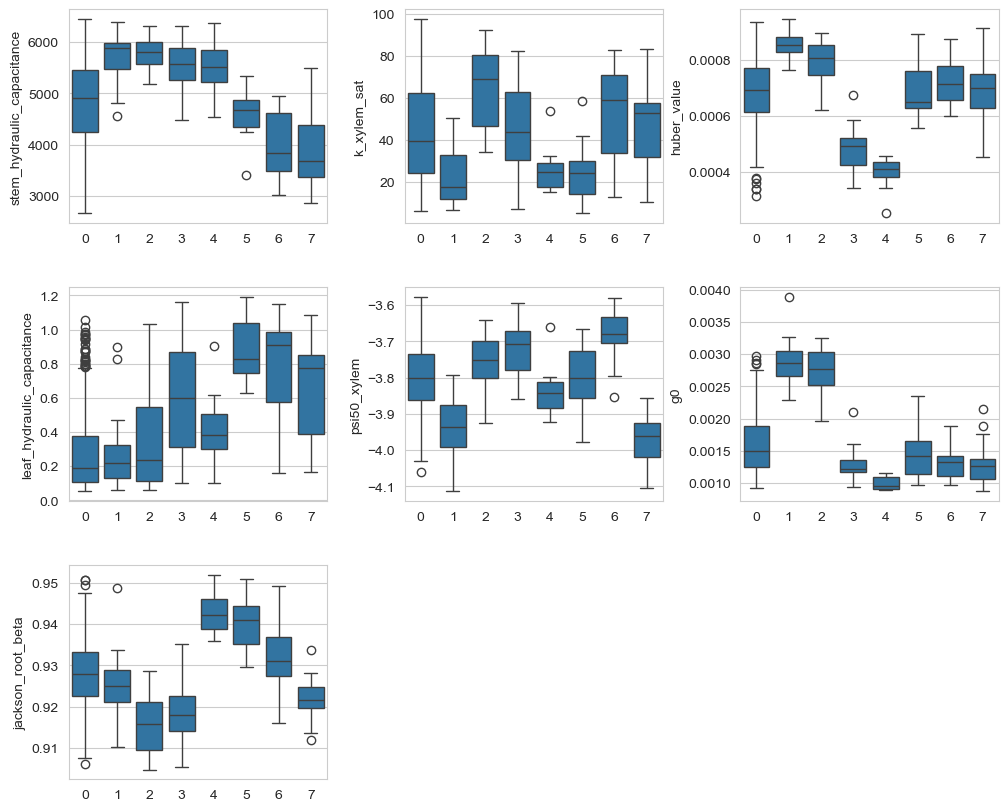

In [40]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    sns.boxplot(x = labels, y = df_mean[var], ax=ax)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

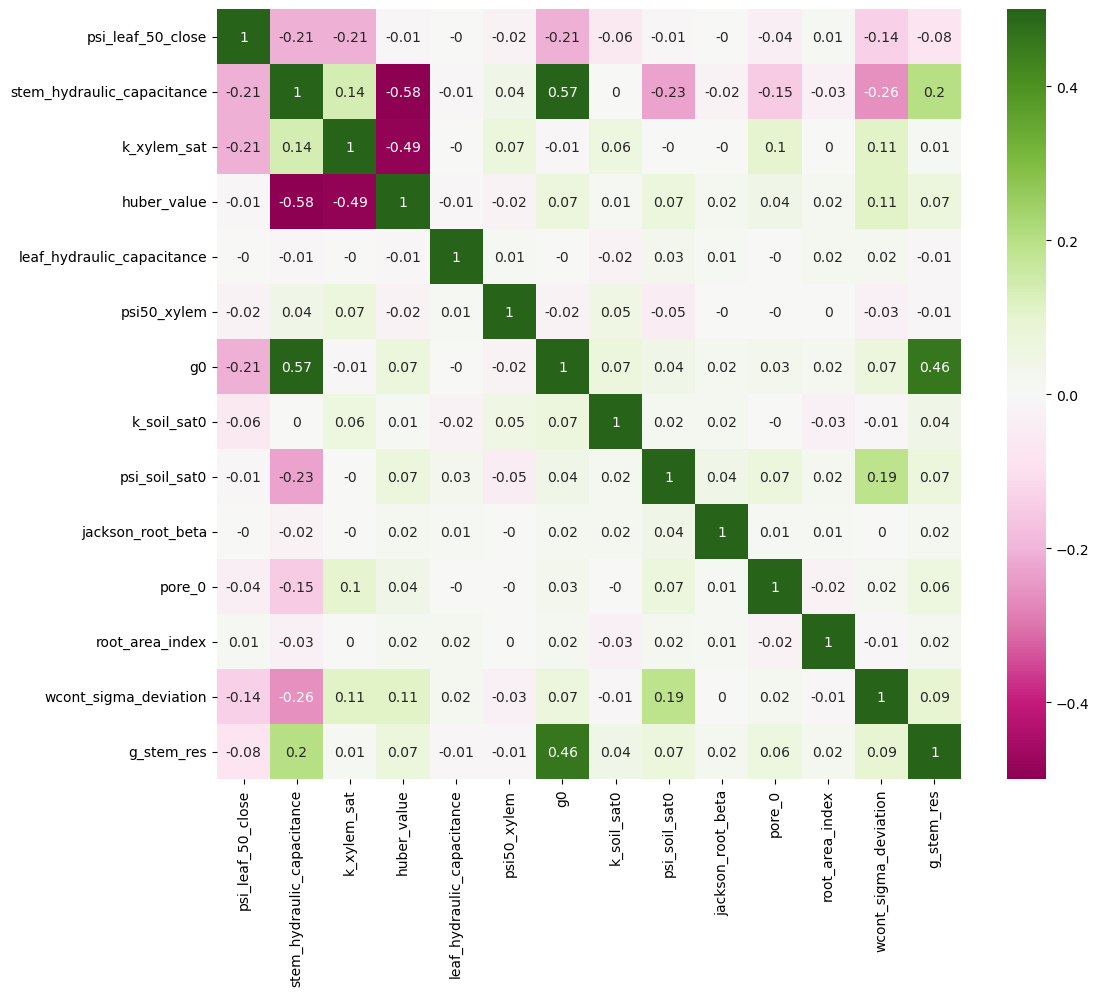

In [29]:
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")
plt.savefig(f"{post_path}/figure_corelation4.png", bbox_inches='tight', dpi = 300)